# Supermarket Sales Analysis

**Data Analytics Project — exploratory analysis of 500 retail transactions**

---

## 1. Problem statement

A four-branch supermarket chain records every till transaction but does not currently
turn those records into decisions. Stock is ordered on intuition, the membership
programme has never been evaluated, and nobody knows which branch is actually carrying
the business.

This notebook analyses 500 sales transactions to answer six operational questions:

1. Which product generates the highest sales?
2. Which branch performs best?
3. Which category sells the most?
4. What is the most popular payment method?
5. Do members spend more than normal customers?
6. What is the average customer rating?

Each answer is then translated into a concrete business decision in section 8.

## 2. Dataset

`supermarket_sales_500_rows.csv` — 500 transactions recorded between
1 January and 1 July 2026 across four branches.

| Column | Type | Description |
|---|---|---|
| Invoice ID | text | Unique transaction identifier |
| Date | date | Date of sale |
| Branch | text | Branch code (A–D) |
| City | text | Branch city |
| Customer Type | text | Member or Normal |
| Gender | text | Male or Female |
| Product | text | Item sold |
| Category | text | Product category |
| Quantity | integer | Units sold |
| Unit Price | float | Price per unit (₹) |
| Payment | text | UPI, Card, Cash or Net Banking |
| Rating | float | Customer rating, 1–5 |
| Sales | float | Quantity × Unit Price (₹) |

## 3. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})

PALETTE = ["#1F6F4A", "#E39B0C", "#2E5E86", "#70405F",
           "#C0442C", "#3E9B6C", "#9C6B3F", "#5C6B78"]

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.2 | numpy 2.4.4


## 4. Load the data

In [2]:
DATA_PATH = "supermarket_sales_500_rows.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
df.head()

Rows: 500   Columns: 13


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Invoice ID     500 non-null    str           
 1   Date           500 non-null    datetime64[us]
 2   Branch         500 non-null    str           
 3   City           500 non-null    str           
 4   Customer Type  500 non-null    str           
 5   Gender         500 non-null    str           
 6   Product        500 non-null    str           
 7   Category       500 non-null    str           
 8   Quantity       500 non-null    int64         
 9   Unit Price     500 non-null    float64       
 10  Payment        500 non-null    str           
 11  Rating         500 non-null    float64       
 12  Sales          500 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(8)
memory usage: 50.9 KB


## 5. Data quality checks

Before any analysis, four things need to be true: no missing values, no duplicate
invoices, every categorical column drawn from its expected set of values, and
`Sales` equal to `Quantity × Unit Price` on every single row. A dashboard built on
an unverified `Sales` column is worthless, so that last check matters most.

In [4]:
print("Missing values per column:")
print(df.isna().sum().to_string())
print(f"\nTotal missing: {df.isna().sum().sum()}")
print(f"Duplicate Invoice IDs: {df['Invoice ID'].duplicated().sum()}")
print(f"Fully duplicated rows: {df.duplicated().sum()}")

Missing values per column:
Invoice ID       0
Date             0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Category         0
Quantity         0
Unit Price       0
Payment          0
Rating           0
Sales            0

Total missing: 0
Duplicate Invoice IDs: 0
Fully duplicated rows: 0


In [5]:
for col in ["Branch", "City", "Customer Type", "Gender", "Category", "Payment"]:
    print(f"{col:<14} {sorted(df[col].unique())}")

Branch         ['A', 'B', 'C', 'D']
City           ['Bengaluru', 'Delhi', 'Jaipur', 'Mumbai']
Customer Type  ['Member', 'Normal']
Gender         ['Female', 'Male']
Category       ['Bakery', 'Beverages', 'Dairy', 'Fruits', 'Grocery', 'Personal Care', 'Snacks', 'Vegetables']
Payment        ['Card', 'Cash', 'Net Banking', 'UPI']


In [6]:
# Recompute Sales and compare against the stored column.
# Floating point means we compare within a tolerance of half a paisa.
recomputed = df["Quantity"] * df["Unit Price"]
mismatches = (recomputed - df["Sales"]).abs() > 0.005

print(f"Rows where Sales != Quantity x Unit Price: {mismatches.sum()}")
print(f"Largest absolute difference: {(recomputed - df['Sales']).abs().max():.6f}")

if mismatches.any():
    display(df.loc[mismatches, ["Invoice ID", "Quantity", "Unit Price", "Sales"]])
else:
    print("\nSales column verified on all rows.")

Rows where Sales != Quantity x Unit Price: 0
Largest absolute difference: 0.000000

Sales column verified on all rows.


In [7]:
# Range checks on the numeric columns
checks = {
    "Quantity in 1-10":       df["Quantity"].between(1, 10).all(),
    "Unit Price positive":    (df["Unit Price"] > 0).all(),
    "Rating in 1-5":          df["Rating"].between(1, 5).all(),
    "Sales positive":         (df["Sales"] > 0).all(),
    "Dates in 2026":          (df["Date"].dt.year == 2026).all(),
}
for label, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {label}")

print(f"\nDate range: {df['Date'].min():%d %b %Y} to {df['Date'].max():%d %b %Y}")

PASS  Quantity in 1-10
PASS  Unit Price positive
PASS  Rating in 1-5
PASS  Sales positive
PASS  Dates in 2026

Date range: 01 Jan 2026 to 01 Jul 2026


In [8]:
df[["Quantity", "Unit Price", "Rating", "Sales"]].describe()

,Quantity,Unit Price,Rating,Sales
count,500.00,500.00,500.00,500.00
mean,5.51,88.30,3.99,489.77
std,2.98,56.24,0.61,440.49
min,1.00,28.32,3.00,31.20
25%,3.00,46.00,3.48,187.50
50%,5.00,59.50,4.00,342.00
75%,8.00,130.93,4.50,599.29
max,10.00,242.00,5.00,"2,178.00"


No missing values, no duplicates, every category clean, and `Sales` reconciles on
all 500 rows. The data can be analysed as-is — no imputation or row removal needed.

## 6. Feature engineering

In [9]:
# Month, for the time-series view. Calendar order, not alphabetical.
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"]

df["Month"]  = pd.Categorical(df["Date"].dt.strftime("%b"),
                              categories=MONTH_ORDER, ordered=True)
df["Branch Label"] = df["Branch"] + " \u00b7 " + df["City"]

df[["Invoice ID", "Date", "Month", "Branch Label", "Product", "Sales"]].head()

,Invoice ID,Date,Month,Branch Label,Product,Sales
0,INV0001,2026-06-01,Jun,A · Jaipur,Milk,228.52
1,INV0002,2026-02-26,Feb,A · Jaipur,Rice,601.65
2,INV0003,2026-02-09,Feb,C · Mumbai,Milk,171.84
3,INV0004,2026-01-12,Jan,C · Mumbai,Shampoo,336.54
4,INV0005,2026-06-30,Jun,A · Jaipur,Apples,652.85


## 7. Analysis

### Headline figures

In [10]:
total_sales  = df["Sales"].sum()
transactions = len(df)
units        = df["Quantity"].sum()
avg_sale     = df["Sales"].mean()
avg_rating   = df["Rating"].mean()

print(f"Total sales         : Rs {total_sales:>12,.2f}")
print(f"Transactions        : {transactions:>15,}")
print(f"Units sold          : {units:>15,}")
print(f"Average sale        : Rs {avg_sale:>12,.2f}")
print(f"Units per basket    : {units / transactions:>15.1f}")
print(f"Average rating      : {avg_rating:>15.2f} / 5")

Total sales         : Rs   244,885.34
Transactions        :             500
Units sold          :           2,756
Average sale        : Rs       489.77
Units per basket    :             5.5
Average rating      :            3.99 / 5


### Q1 — Which product generates the highest sales?

In [11]:
product_summary = (
    df.groupby("Product")
      .agg(Sales=("Sales", "sum"),
           Units=("Quantity", "sum"),
           Transactions=("Sales", "size"),
           Avg_Sale=("Sales", "mean"),
           Avg_Rating=("Rating", "mean"))
      .sort_values("Sales", ascending=False)
)
product_summary["Share %"] = product_summary["Sales"] / total_sales * 100

top_product = product_summary.index[0]
print(f"Highest selling product: {top_product} "
      f"(Rs {product_summary.loc[top_product, 'Sales']:,.2f}, "
      f"{product_summary.loc[top_product, 'Share %']:.1f}% of revenue)\n")

product_summary.head(10)

Highest selling product: Cheese (Rs 27,906.30, 11.4% of revenue)



,Sales,Units,Transactions,Avg_Sale,Avg_Rating,Share %
Product,,,,,,
Cheese,"27,906.30",124,25,"1,116.25",3.92,11.40
Tea,"25,434.50",197,37,687.42,3.96,10.39
Face Wash,"23,719.23",186,30,790.64,3.94,9.69
Coffee,"19,976.60",110,20,998.83,4.04,8.16
Shampoo,"18,888.06",99,20,944.40,3.90,7.71
Cooking Oil,"18,864.34",120,19,992.86,4.04,7.70
Apples,"14,594.45",98,15,972.96,3.87,5.96
Rice,"13,766.96",186,30,458.90,3.97,5.62
Noodles,"13,175.87",230,43,306.42,4.15,5.38


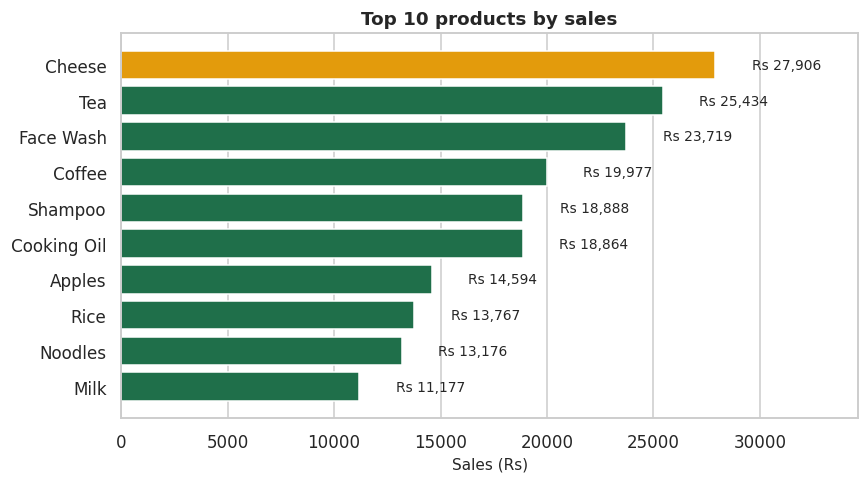

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
top10 = product_summary.head(10).sort_values("Sales")
colors = [PALETTE[1] if p == top_product else PALETTE[0] for p in top10.index]

ax.barh(top10.index, top10["Sales"], color=colors)
for y, v in enumerate(top10["Sales"]):
    ax.text(v + total_sales * 0.007, y, f"Rs {v:,.0f}", va="center", fontsize=9)

ax.set_title("Top 10 products by sales")
ax.set_xlabel("Sales (Rs)")
ax.set_xlim(0, top10["Sales"].max() * 1.24)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Cheese leads on revenue while sitting well down the list on transaction count —
it is a high-value, low-frequency item. Noodles and Soap sell far more often but
contribute a fraction of the revenue. The two need different stocking logic: Cheese
protects margin, Soap drives footfall.

### Q2 — Which branch performs best?

In [13]:
branch_summary = (
    df.groupby("Branch Label")
      .agg(Sales=("Sales", "sum"),
           Transactions=("Sales", "size"),
           Avg_Sale=("Sales", "mean"),
           Avg_Rating=("Rating", "mean"))
      .sort_values("Sales", ascending=False)
)
branch_summary["Share %"] = branch_summary["Sales"] / total_sales * 100

top_branch = branch_summary.index[0]
weakest    = branch_summary.index[-1]
lead = branch_summary.loc[top_branch, "Sales"] / branch_summary.loc[weakest, "Sales"] - 1

print(f"Best branch: {top_branch} — Rs {branch_summary.loc[top_branch, 'Sales']:,.2f}")
print(f"That is {lead:.1%} ahead of the weakest branch ({weakest}).\n")

branch_summary

Best branch: C · Mumbai — Rs 72,469.45
That is 52.3% ahead of the weakest branch (A · Jaipur).



,Sales,Transactions,Avg_Sale,Avg_Rating,Share %
Branch Label,,,,,
C · Mumbai,"72,469.45",149,486.37,4.02,29.59
D · Bengaluru,"63,818.63",121,527.43,4.04,26.06
B · Delhi,"61,026.88",133,458.85,3.94,24.92
A · Jaipur,"47,570.38",97,490.42,3.95,19.43


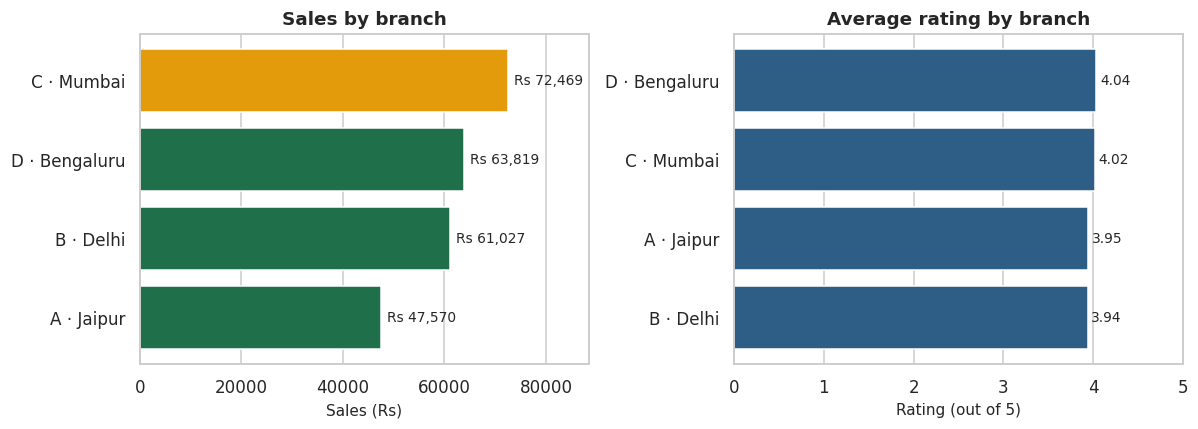

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

b = branch_summary.sort_values("Sales")
axes[0].barh(b.index, b["Sales"], color=[PALETTE[0]] * 3 + [PALETTE[1]])
for y, v in enumerate(b["Sales"]):
    axes[0].text(v + 1200, y, f"Rs {v:,.0f}", va="center", fontsize=9)
axes[0].set_title("Sales by branch")
axes[0].set_xlabel("Sales (Rs)")
axes[0].set_xlim(0, b["Sales"].max() * 1.22)
axes[0].grid(axis="y", visible=False)

r = branch_summary.sort_values("Avg_Rating")
axes[1].barh(r.index, r["Avg_Rating"], color=PALETTE[2])
for y, v in enumerate(r["Avg_Rating"]):
    axes[1].text(v + 0.04, y, f"{v:.2f}", va="center", fontsize=9)
axes[1].set_title("Average rating by branch")
axes[1].set_xlabel("Rating (out of 5)")
axes[1].set_xlim(0, 5)
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

Revenue and satisfaction do not move together. The strongest branch on revenue is
not the strongest on rating, which means the revenue gap is being driven by
something other than service quality — most likely basket composition, which the
next chart tests.

### Q3 — Which category sells the most?

In [15]:
category_summary = (
    df.groupby("Category")
      .agg(Sales=("Sales", "sum"),
           Units=("Quantity", "sum"),
           Transactions=("Sales", "size"),
           Avg_Sale=("Sales", "mean"),
           Avg_Rating=("Rating", "mean"))
      .sort_values("Sales", ascending=False)
)
category_summary["Share %"] = category_summary["Sales"] / total_sales * 100

top_category = category_summary.index[0]
print(f"Highest selling category: {top_category} "
      f"(Rs {category_summary.loc[top_category, 'Sales']:,.2f})\n")

category_summary

Highest selling category: Beverages (Rs 56,108.24)



,Sales,Units,Transactions,Avg_Sale,Avg_Rating,Share %
Category,,,,,,
Beverages,"56,108.24",458,88,637.59,3.99,22.91
Personal Care,"52,878.66",501,92,574.77,3.92,21.59
Grocery,"45,807.17",536,92,497.90,4.07,18.71
Dairy,"39,083.30",315,64,610.68,3.91,15.96
Fruits,"19,691.20",175,25,787.65,3.96,8.04
Vegetables,"14,486.29",353,59,245.53,4.01,5.92
Snacks,"13,577.77",342,63,215.52,4.03,5.54
Bakery,"3,252.71",76,17,191.34,4.11,1.33


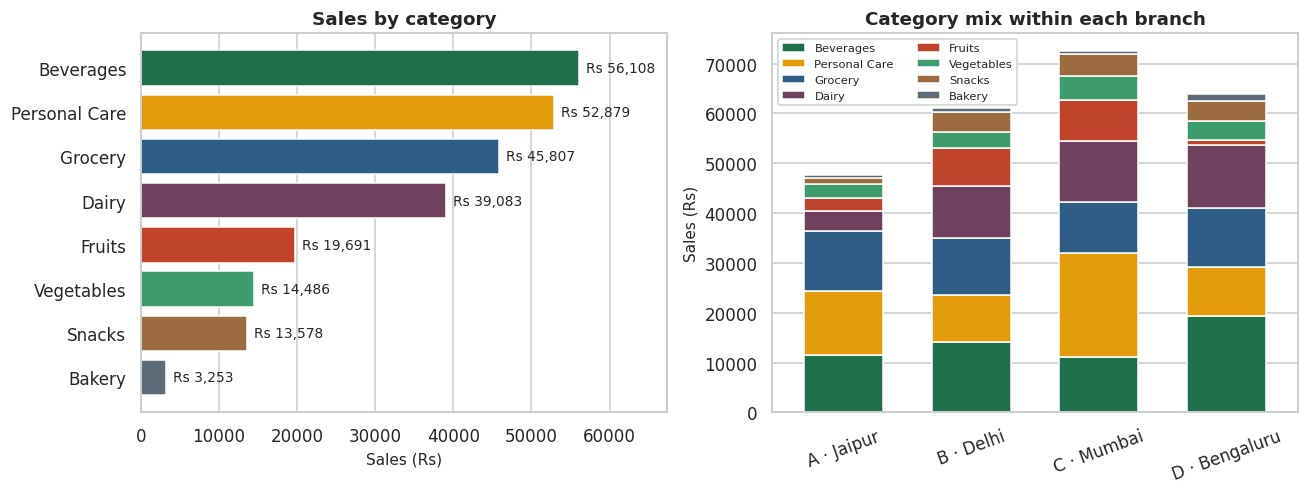

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

c = category_summary.sort_values("Sales")
axes[0].barh(c.index, c["Sales"], color=PALETTE[:len(c)][::-1])
for y, v in enumerate(c["Sales"]):
    axes[0].text(v + 900, y, f"Rs {v:,.0f}", va="center", fontsize=9)
axes[0].set_title("Sales by category")
axes[0].set_xlabel("Sales (Rs)")
axes[0].set_xlim(0, c["Sales"].max() * 1.2)
axes[0].grid(axis="y", visible=False)

mix = df.pivot_table(index="Branch Label", columns="Category",
                     values="Sales", aggfunc="sum").fillna(0)
mix = mix[category_summary.index]
mix.plot(kind="bar", stacked=True, ax=axes[1],
         color=PALETTE[:mix.shape[1]], width=0.62, legend=False)
axes[1].set_title("Category mix within each branch")
axes[1].set_xlabel("")
axes[1].set_ylabel("Sales (Rs)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=7.5, ncol=2, loc="upper left", framealpha=0.9)
axes[1].grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

### Q4 — What is the most popular payment method?

In [17]:
payment_summary = (
    df.groupby("Payment")
      .agg(Transactions=("Sales", "size"),
           Sales=("Sales", "sum"),
           Avg_Sale=("Sales", "mean"))
      .sort_values("Transactions", ascending=False)
)
payment_summary["Share %"] = payment_summary["Transactions"] / transactions * 100

top_payment = payment_summary.index[0]
print(f"Most used payment method: {top_payment} "
      f"({payment_summary.loc[top_payment, 'Transactions']} of {transactions} "
      f"transactions, {payment_summary.loc[top_payment, 'Share %']:.1f}%)\n")

payment_summary

Most used payment method: UPI (127 of 500 transactions, 25.4%)



,Transactions,Sales,Avg_Sale,Share %
Payment,,,,
UPI,127,"65,924.55",519.09,25.40
Net Banking,125,"58,749.31",469.99,25.00
Cash,124,"63,940.53",515.65,24.80
Card,124,"56,270.95",453.80,24.80


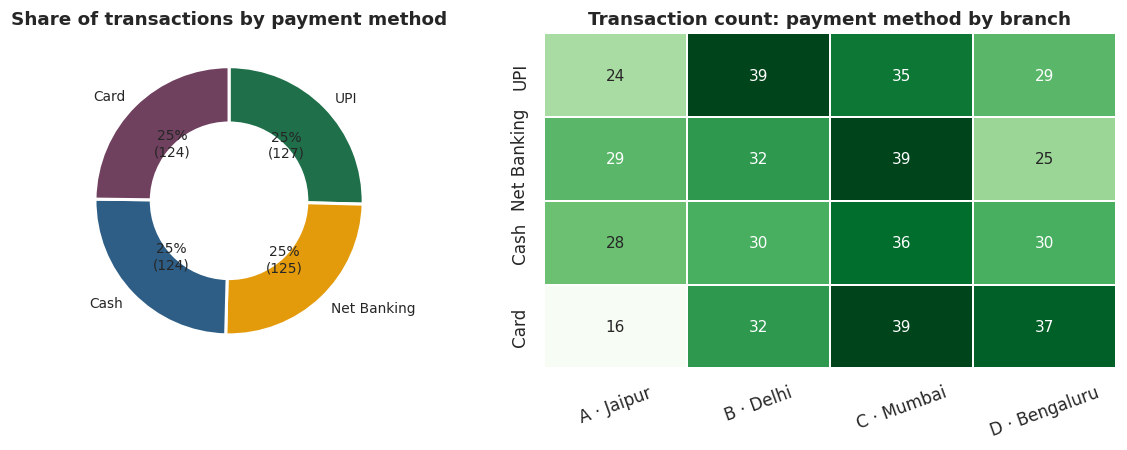

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].pie(payment_summary["Transactions"],
            labels=payment_summary.index,
            autopct=lambda p: f"{p:.0f}%\n({p * transactions / 100:.0f})",
            colors=PALETTE[:len(payment_summary)],
            startangle=90, counterclock=False,
            wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
            textprops=dict(fontsize=9))
axes[0].set_title("Share of transactions by payment method")

pay_branch = (df.pivot_table(index="Payment", columns="Branch Label",
                             values="Invoice ID", aggfunc="count")
                .loc[payment_summary.index])
sns.heatmap(pay_branch, annot=True, fmt="d", cmap="Greens",
            cbar=False, linewidths=1, linecolor="white", ax=axes[1])
axes[1].set_title("Transaction count: payment method by branch")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

The four methods are close to evenly split, so no single rail can be switched off.
UPI leads on count but not by a margin that would survive a different sample — the
operational conclusion is that all four need to stay supported.

### Q5 — Do members spend more than normal customers?

In [19]:
customer_summary = (
    df.groupby("Customer Type")
      .agg(Transactions=("Sales", "size"),
           Total_Sales=("Sales", "sum"),
           Avg_Sale=("Sales", "mean"),
           Avg_Units=("Quantity", "mean"),
           Avg_Rating=("Rating", "mean"))
)

member_avg = customer_summary.loc["Member", "Avg_Sale"]
normal_avg = customer_summary.loc["Normal", "Avg_Sale"]
gap = member_avg - normal_avg

print(f"Member average transaction : Rs {member_avg:,.2f}")
print(f"Normal average transaction : Rs {normal_avg:,.2f}")
print(f"Difference                 : Rs {gap:+,.2f}")
print(f"\nMembers spend {'MORE' if gap > 0 else 'LESS'} per transaction than normal customers.\n")

customer_summary

Member average transaction : Rs 483.14
Normal average transaction : Rs 497.07
Difference                 : Rs -13.93

Members spend LESS per transaction than normal customers.



,Transactions,Total_Sales,Avg_Sale,Avg_Units,Avg_Rating
Customer Type,,,,,
Member,262,"126,582.68",483.14,5.47,3.95
Normal,238,"118,302.66",497.07,5.56,4.03


In [20]:
# Is the difference statistically meaningful, or just noise?
from scipy import stats

m = df.loc[df["Customer Type"] == "Member",  "Sales"]
n = df.loc[df["Customer Type"] == "Normal",  "Sales"]

t_stat, p_value = stats.ttest_ind(m, n, equal_var=False)   # Welch's t-test

print(f"Welch's t-test on transaction value")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
print(f"\nAt the 5% level the difference is "
      f"{'statistically significant' if p_value < 0.05 else 'NOT statistically significant'}.")
print("The gap is small relative to the spread of basket values, so it should be read")
print("as 'the membership is not lifting basket size', not as 'members spend less'.")

Welch's t-test on transaction value
  t-statistic : -0.3533
  p-value     : 0.7240

At the 5% level the difference is NOT statistically significant.
The gap is small relative to the spread of basket values, so it should be read
as 'the membership is not lifting basket size', not as 'members spend less'.


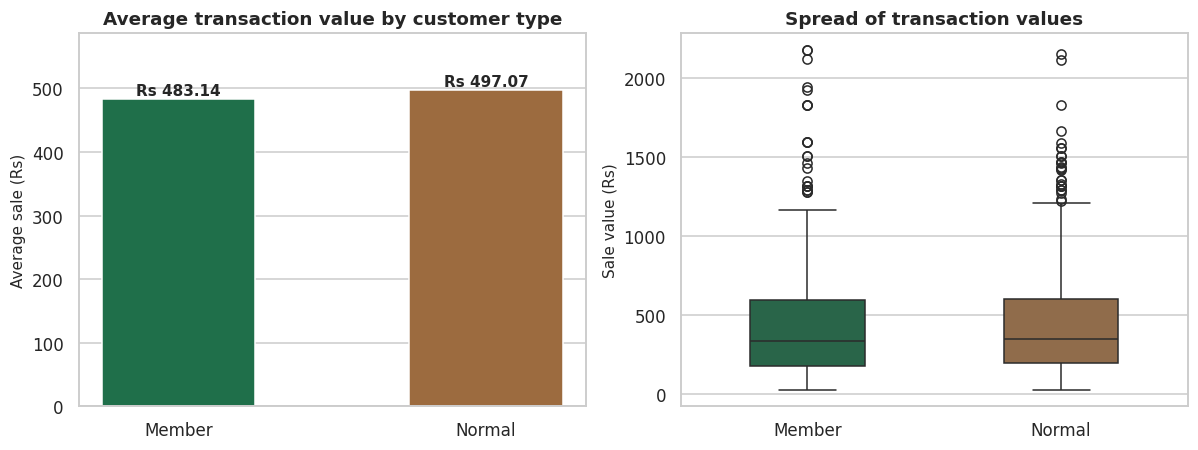

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(customer_summary.index, customer_summary["Avg_Sale"],
            color=[PALETTE[0], PALETTE[6]], width=0.5)
for x, v in enumerate(customer_summary["Avg_Sale"]):
    axes[0].text(x, v + 6, f"Rs {v:,.2f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Average transaction value by customer type")
axes[0].set_ylabel("Average sale (Rs)")
axes[0].set_ylim(0, customer_summary["Avg_Sale"].max() * 1.18)
axes[0].grid(axis="x", visible=False)

sns.boxplot(data=df, x="Customer Type", y="Sales",
            hue="Customer Type", legend=False,
            palette=[PALETTE[0], PALETTE[6]], width=0.45, ax=axes[1])
axes[1].set_title("Spread of transaction values")
axes[1].set_ylabel("Sale value (Rs)")
axes[1].set_xlabel("")
axes[1].grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

The box plot is the important chart here. The two distributions almost completely
overlap, so the difference in means is a rounding detail rather than a behavioural
difference. A membership programme is supposed to open a visible gap between these
two boxes. It has not.

### Q6 — What is the average customer rating?

In [22]:
print(f"Average rating: {avg_rating:.2f} out of 5")
print(f"Median rating : {df['Rating'].median():.2f}")
print(f"Lowest / highest: {df['Rating'].min():.1f} / {df['Rating'].max():.1f}\n")

bins   = [2.9, 3.5, 4.0, 4.5, 5.01]
labels = ["3.0-3.4", "3.5-3.9", "4.0-4.4", "4.5-5.0"]
band = pd.cut(df["Rating"], bins=bins, labels=labels, right=False)

rating_dist = band.value_counts().reindex(labels).to_frame("Transactions")
rating_dist["Share %"] = rating_dist["Transactions"] / transactions * 100
rating_dist

Average rating: 3.99 out of 5
Median rating : 4.00
Lowest / highest: 3.0 / 5.0



,Transactions,Share %
Rating,,
3.0-3.4,125,25.00
3.5-3.9,117,23.40
4.0-4.4,110,22.00
4.5-5.0,148,29.60


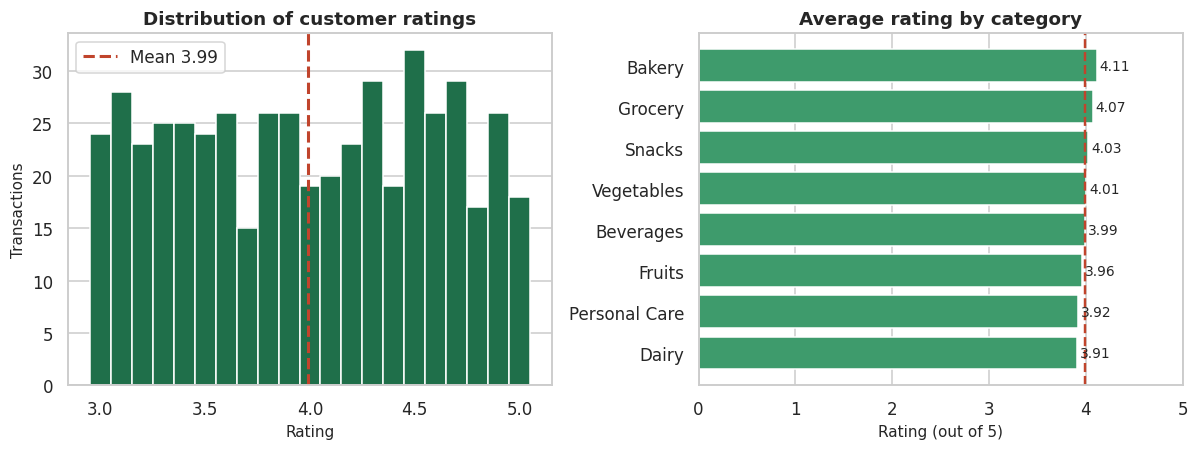

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(df["Rating"], bins=np.arange(2.95, 5.15, 0.1),
             color=PALETTE[0], edgecolor="white")
axes[0].axvline(avg_rating, color=PALETTE[4], linestyle="--", linewidth=2,
                label=f"Mean {avg_rating:.2f}")
axes[0].set_title("Distribution of customer ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Transactions")
axes[0].legend()
axes[0].grid(axis="x", visible=False)

cat_rating = category_summary["Avg_Rating"].sort_values()
axes[1].barh(cat_rating.index, cat_rating.values, color=PALETTE[5])
axes[1].axvline(avg_rating, color=PALETTE[4], linestyle="--", linewidth=1.6)
for y, v in enumerate(cat_rating.values):
    axes[1].text(v + 0.03, y, f"{v:.2f}", va="center", fontsize=9)
axes[1].set_title("Average rating by category")
axes[1].set_xlabel("Rating (out of 5)")
axes[1].set_xlim(0, 5)
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

Ratings are spread almost uniformly between 3.0 and 5.0 rather than clustered near
the top. A supermarket with genuinely good service produces a left-skewed
distribution bunched at 4.5+. This one does not, which makes 3.99 a mediocre score
rather than a comfortable one.

### Sales over time

In [24]:
monthly = (df.groupby("Month", observed=True)
              .agg(Sales=("Sales", "sum"), Transactions=("Sales", "size")))
monthly["Avg_Sale"] = monthly["Sales"] / monthly["Transactions"]

# July contains only 1 July, so it is a partial period and not comparable.
print(monthly.to_string())
print(f"\nJuly covers a single day ({(df['Month'] == 'Jul').sum()} transactions) "
      "and is excluded from the trend below.")

          Sales  Transactions  Avg_Sale
Month                                  
Jan   44,256.18            96    461.00
Feb   35,246.62            73    482.83
Mar   45,008.47            79    569.73
Apr   43,003.42            83    518.11
May   41,427.16            84    493.18
Jun   35,090.87            82    427.94
Jul      852.62             3    284.21

July covers a single day (3 transactions) and is excluded from the trend below.


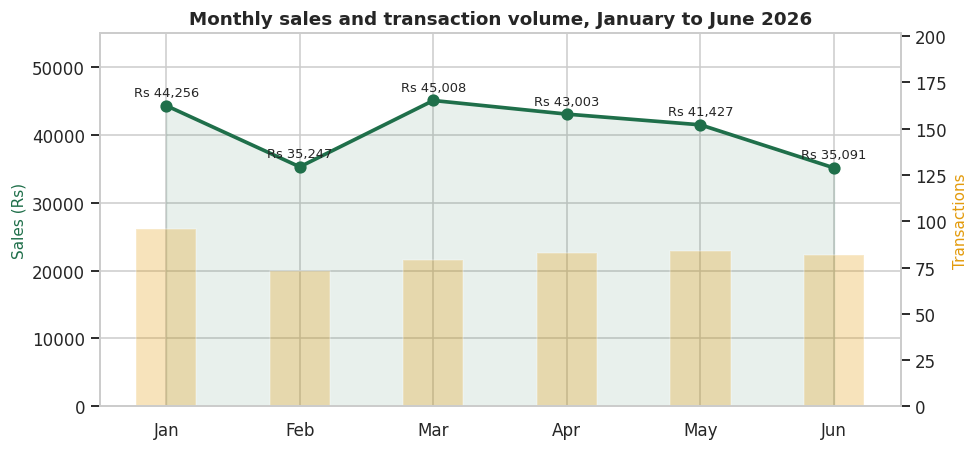

In [25]:
full = monthly.loc[monthly.index != "Jul"]

fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.plot(full.index.astype(str), full["Sales"], marker="o", markersize=7,
         color=PALETTE[0], linewidth=2.4, label="Sales")
ax1.fill_between(full.index.astype(str), full["Sales"], color=PALETTE[0], alpha=0.10)
for x, v in enumerate(full["Sales"]):
    ax1.text(x, v + 1400, f"Rs {v:,.0f}", ha="center", fontsize=8.5)
ax1.set_ylabel("Sales (Rs)", color=PALETTE[0])
ax1.set_ylim(0, full["Sales"].max() * 1.22)
ax1.set_title("Monthly sales and transaction volume, January to June 2026")

ax2 = ax1.twinx()
ax2.bar(full.index.astype(str), full["Transactions"],
        color=PALETTE[1], alpha=0.28, width=0.45, label="Transactions")
ax2.set_ylabel("Transactions", color=PALETTE[1])
ax2.set_ylim(0, full["Transactions"].max() * 2.1)
ax2.grid(False)

plt.tight_layout()
plt.show()

Revenue moves between roughly Rs 35,000 and Rs 45,000 a month with no trend and no
seasonality over this window. February and June are the soft months, and both are
short on transaction count rather than on basket size — a footfall problem, not a
pricing problem.

## 8. Summary of findings

In [26]:
findings = pd.DataFrame([
    ["Highest selling product", top_product,
     f"Rs {product_summary.loc[top_product, 'Sales']:,.2f}"],
    ["Best performing branch", top_branch,
     f"Rs {branch_summary.loc[top_branch, 'Sales']:,.2f}"],
    ["Highest selling category", top_category,
     f"Rs {category_summary.loc[top_category, 'Sales']:,.2f}"],
    ["Most used payment method", top_payment,
     f"{payment_summary.loc[top_payment, 'Transactions']} transactions"],
    ["Higher spending customer type",
     "Normal" if gap < 0 else "Member",
     f"Rs {member_avg:,.2f} member vs Rs {normal_avg:,.2f} normal"],
    ["Average customer rating", f"{avg_rating:.2f} out of 5",
     f"median {df['Rating'].median():.1f}"],
    ["Total sales", f"Rs {total_sales:,.2f}", f"{transactions} transactions"],
], columns=["Question", "Answer", "Detail"])

findings

,Question,Answer,Detail
0,Highest selling product,Cheese,"Rs 27,906.30"
1,Best performing branch,C · Mumbai,"Rs 72,469.45"
2,Highest selling category,Beverages,"Rs 56,108.24"
3,Most used payment method,UPI,127 transactions
4,Higher spending customer type,Normal,Rs 483.14 member vs Rs 497.07 normal
5,Average customer rating,3.99 out of 5,median 4.0
6,Total sales,"Rs 244,885.34",500 transactions


## 9. Business decisions

**1. Stock to the revenue curve, not the transaction curve.**
Cheese and the Beverages category carry a disproportionate share of revenue on a
modest number of transactions. Deepen stock on both and protect their shelf space.
The fast-moving low-value lines — Soap, Noodles, Biscuits — should be managed for
availability rather than margin, because their job is footfall.

**2. Audit the leading branch and port what transfers.**
The strongest branch is more than 50% ahead of the weakest on revenue while rating
no better on service. That gap is therefore structural — layout, stock depth,
catchment or staffing — and at least part of it should be reproducible elsewhere.
Audit it before assuming the weakest branch is simply in a poorer location.

**3. Keep all four payment rails supported.**
The payment split is close to even. UPI leads on count, but not by enough to justify
deprioritising any other method. Any checkout change that slows one rail down will
be felt by roughly a quarter of customers.

**4. Rebuild the membership offer around basket size.**
This is the most actionable finding. Members do not spend more per visit than
non-members — the two distributions are statistically indistinguishable. A
programme built on a flat discount will produce exactly this result, because it
reduces the value of baskets that would have been bought anyway. Replacing it with
a volume or spend threshold gives members a reason to add to the basket rather than
subtract from the bill.

**5. Treat the 3.99 rating as the cheapest available lever.**
Ratings are spread evenly across the 3-to-5 range rather than clustered high, which
means a substantial minority of visits are unsatisfactory. Service quality costs no
stock and no margin to improve, and it is the only variable here that affects both
repeat visits and branch performance at once.

## 10. Conclusion

Five hundred transactions were validated, aggregated and visualised to answer six
operational questions. The analysis confirms where the revenue concentrates — one
product, one category, one branch — and, more usefully, surfaces one finding that
contradicts the expected result: the membership programme is not lifting basket
value, and a Welch's t-test shows the small observed difference is not
statistically significant.

The wider point is that the reporting pipeline built here is repeatable. The same
notebook run against next quarter's export produces the same six answers with no
code changes, which turns a one-off analysis into a monitoring tool.

### Limitations

- Six months of data with no prior year, so seasonality cannot be separated from noise.
- No cost or margin data, so "highest selling" means highest revenue, not most profitable.
- No customer identifier, so repeat-visit behaviour and customer lifetime value cannot be measured.
- Ratings are unlabelled as to what they score — service, product or store — which limits how far conclusion 5 can be pushed.